# 📌 Introduction

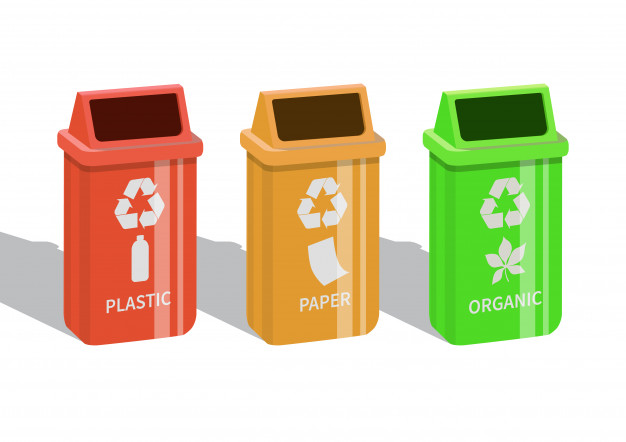

Waste is a significant global issue. Increasing volumes of waste are being generated as the global population and living standards rise. People are increasingly concerned about the production of waste and its effect, and are seeking ways to deal with the problem.

Recycling is the process of converting waste materials into new materials and objects. The recovery of energy from waste materials is often included in this concept. The recyclability of a material depends on its ability to reacquire the properties it had in its original state. It is an alternative to "conventional" waste disposal that can save material and help lower greenhouse gas emissions. Recycling can prevent the waste of potentially useful materials and reduce the consumption of fresh raw materials, thereby reducing: energy usage, air pollution (from incineration), and water pollution (from landfilling).

 **🟢 In this notebook, we will classify waste as organic or recyclable using Convolutional Neural Network (CNN).**

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')
import os

dataset_path = r'C:\Users\LENOVO\Downloads\archive (1)\dataset-resized'

for dirname, subdirs, filenames in os.walk(dataset_path):
    print(dirname)

C:\Users\LENOVO\Downloads\archive (1)\dataset-resized
C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\cardboard
C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\glass
C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\metal
C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\paper
C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\plastic
C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\trash


In [6]:
!pip install "numpy<2" opencv-python

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.5 MB 2.0 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/15.5 MB 3.2 MB/s eta 0:00:05
   ---------- ----------------------------- 3.9/15.5 MB 5.2 MB/s eta 0:00:03
   -------------------- ------------------- 7.9/15.5 MB 8.4 MB/s eta 0:00:01
   --------------------------------- ------ 13.1/15.5 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 11.9 MB/s eta 0:00:00
   ---------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.0 which is incompatible.


In [5]:
train_path = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized"
test_path  = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized"

## Import Libraries

In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization

# Updated import paths for modern Keras / TensorFlow
from keras.utils import img_to_array, load_img, plot_model
from glob import glob

## Visualization

In [7]:
x_data = [] 
y_data = [] 

for category in glob(train_path+'/*'):
    for file in tqdm(glob(category+'/*')):
        img_array=cv2.imread(file)
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
        x_data.append(img_array) 
        y_data.append(category.split("/")[-1])
        
data=pd.DataFrame({'image': x_data,'label': y_data})

100%|███████████████████████████████████████████████████████████████████████████████| 137/137 [00:00<00:00, 339.47it/s]


In [8]:
data.shape

(2527, 2)

In [9]:
from collections import Counter
Counter(y_data)

Counter({'C:\\Users\\LENOVO\\Downloads\\archive (1)\\dataset-resized\\paper': 594,
         'C:\\Users\\LENOVO\\Downloads\\archive (1)\\dataset-resized\\glass': 501,
         'C:\\Users\\LENOVO\\Downloads\\archive (1)\\dataset-resized\\plastic': 482,
         'C:\\Users\\LENOVO\\Downloads\\archive (1)\\dataset-resized\\metal': 410,
         'C:\\Users\\LENOVO\\Downloads\\archive (1)\\dataset-resized\\cardboard': 403,
         'C:\\Users\\LENOVO\\Downloads\\archive (1)\\dataset-resized\\trash': 137})

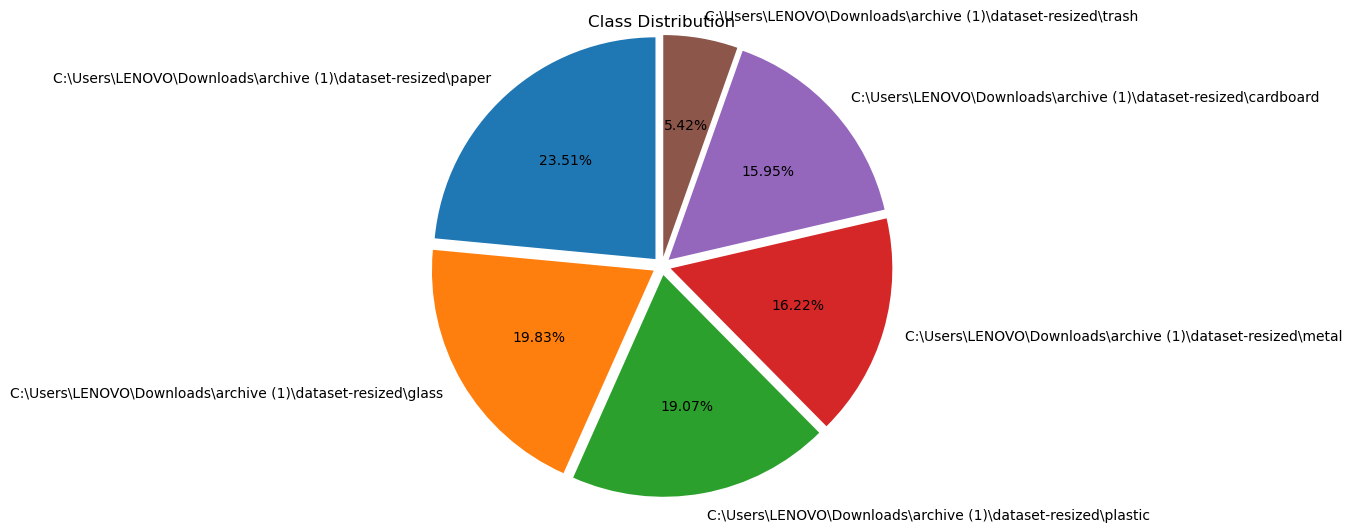

In [10]:
import matplotlib.pyplot as plt

# Get the actual counts and class names from your data
counts = data.label.value_counts()
num_classes = len(counts)

# Generate matching labels and explode values dynamically
labels = counts.index.tolist()
explode = [0.05] * num_classes  # Creates 0.05 spacing for every slice

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    startangle=90,
    explode=explode,
    autopct='%0.2f%%',
    labels=labels,
    radius=1.2
)
plt.title("Class Distribution")
plt.show()

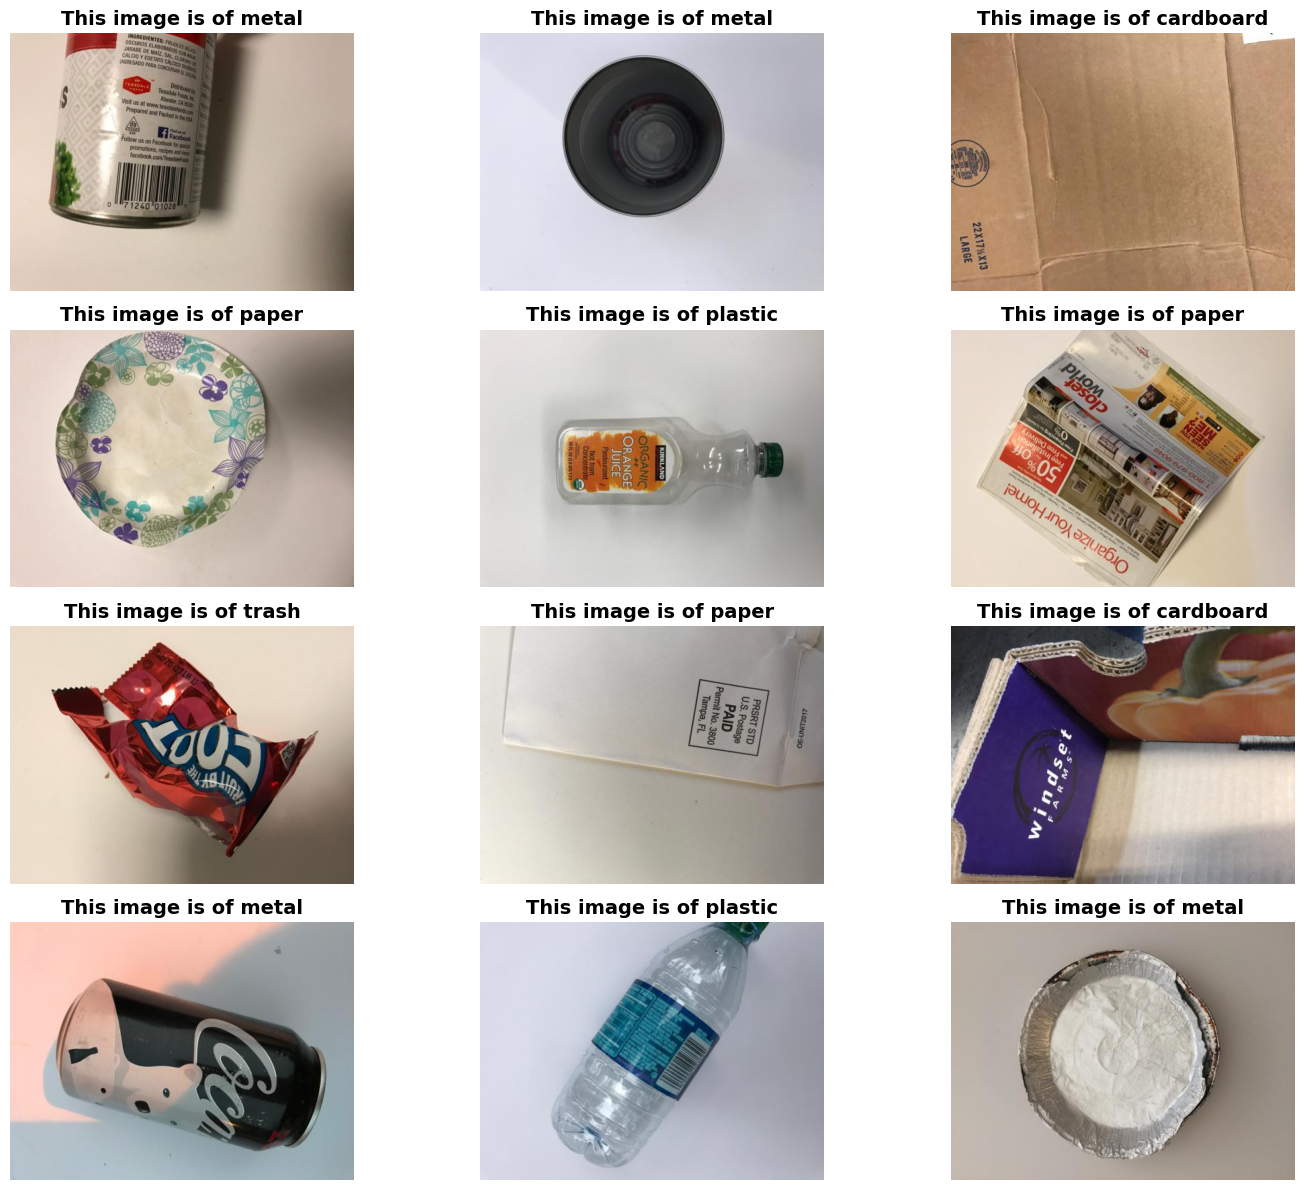

In [13]:
plt.figure(figsize=(15, 12))

for i in range(12):
    # Pick a random index bounded by the dataset length
    index = np.random.randint(len(data))
    
    plt.subplot(4, 3, i + 1)
    plt.title(f'This image is of {data["label"].iloc[index]}', fontdict={'size': 14, 'weight': 'bold'})
    plt.imshow(data['image'].iloc[index])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import os

# Extract just the folder name (e.g. 'paper', 'metal', 'glass')
data['label'] = data['label'].apply(lambda x: os.path.basename(os.path.normpath(x)))

* O -> Organic
* R -> Recyclable

In [14]:
className = glob(train_path + '/*' )
numberOfClass = len(className)
print("Number Of Class: ",numberOfClass)

Number Of Class:  6


# Convolutional Neural Network - CNN

In [15]:
model = Sequential()
model.add(Conv2D(32,(3,3),input_shape = (224,224,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3)))  
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(numberOfClass)) # output
model.add(Activation("sigmoid"))

model.compile(loss = "binary_crossentropy",
              optimizer = "adam",
              metrics = ["accuracy"])

batch_size = 256

In [17]:
plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [16]:
!pip install pydot

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Now initialize your datagen
train_datagen = ImageDataGenerator(rescale=1./255)

In [20]:
test_datagen = ImageDataGenerator(rescale= 1./255)

In [21]:
train_generator = train_datagen.flow_from_directory(
        train_path, 
        target_size= (224,224),
        batch_size = batch_size,
        color_mode= "rgb",
        class_mode= "categorical")

test_generator = test_datagen.flow_from_directory(
        test_path, 
        target_size= (224,224),
        batch_size = batch_size,
        color_mode= "rgb",
        class_mode= "categorical")

Found 2527 images belonging to 6 classes.
Found 2527 images belonging to 6 classes.


In [23]:
hist = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 95s 9s/step - accuracy: 0.1824 - loss: 0.8715 - val_accuracy: 0.1907 - val_loss: 0.4504
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.1899 - loss: 0.5070 - val_accuracy: 0.1927 - val_loss: 0.4432
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.2169 - loss: 0.4849 - val_accuracy: 0.3336 - val_loss: 0.4293
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 0.2825 - loss: 0.4620 - val_accuracy: 0.4298 - val_loss: 0.4007
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - accuracy: 0.3486 - loss: 0.4350 - val_accuracy: 0.4725 - val_loss: 0.3728
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 8s/step - accuracy: 0.3751 - loss: 0.4199 - val_accuracy: 0.5046 - val_loss: 0.3556
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 78s 8s/step - accuracy: 0.3981 - loss: 0.4123 - val_accuracy: 0.5002 - val_loss: 0.3399
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 8s/step - accuracy: 0.4373 - loss: 0.3903 - val_accuracy: 0.5330 - val_loss:

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Enhanced Augmentation Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Update paths to your local directory
train_generator = train_datagen.flow_from_directory(
    r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset=None  # Or set up train/val splits
)

Found 2527 images belonging to 6 classes.


In [27]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 1. Load the pre-trained base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze base layers initially
base_model.trainable = False

# 3. Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(6, activation='softmax')(x)  # 6 classes for TrashNet

# 4. Construct complete model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile for Stage 1 training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Base model defined successfully!")

Base model defined successfully!


In [28]:
# Unfreeze base model for fine-tuning
base_model.trainable = True

# Freeze the first 100 layers and keep the rest trainable
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model unfreezing and re-compilation complete!")

Model unfreezing and re-compilation complete!


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize generator with augmentation and a 20% validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Reserves 20% of data for validation
)

dataset_dir = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized"

# 1. Training Generator (80% of data)
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 2. Validation Generator (20% of data)
val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [31]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 952ms/step - accuracy: 0.2312 - loss: 1.8698 - val_accuracy: 0.3082 - val_loss: 1.6121
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 883ms/step - accuracy: 0.3878 - loss: 1.4952 - val_accuracy: 0.4652 - val_loss: 1.3678
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 870ms/step - accuracy: 0.5242 - loss: 1.2651 - val_accuracy: 0.5547 - val_loss: 1.2400
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 928ms/step - accuracy: 0.5845 - loss: 1.1518 - val_accuracy: 0.5567 - val_loss: 1.1732
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 899ms/step - accuracy: 0.6354 - loss: 1.0060 - val_accuracy: 0.5686 - val_loss: 1.1244
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6803 - loss: 0.9085 - val_accuracy: 0.5765 - val_loss: 1.0941
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 928ms/step - accuracy: 0.6961 - loss: 0.8431 - val_accuracy: 0.6064 - val_loss: 1.0435
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 886ms/step - accuracy: 0.7258 - loss: 0.7725 - val_accurac

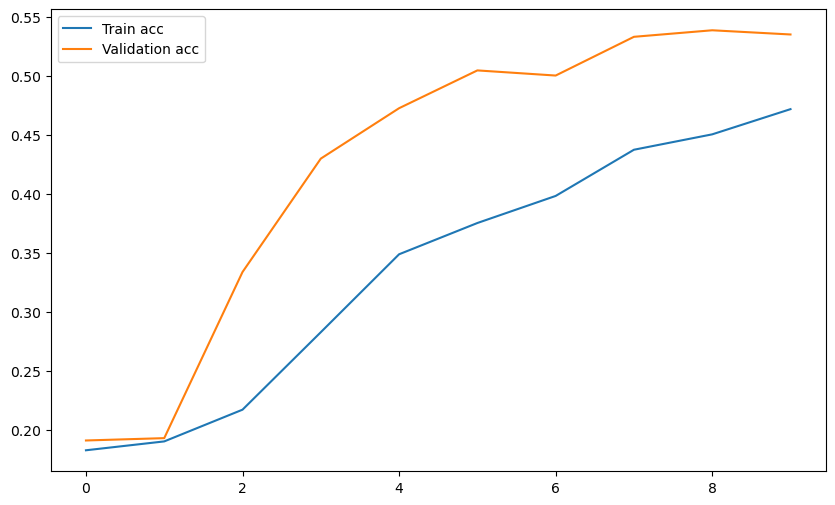

In [37]:
plt.figure(figsize=[10,6])
plt.plot(hist.history["accuracy"], label = "Train acc")
plt.plot(hist.history["val_accuracy"], label = "Validation acc")
plt.legend()
plt.show()

In [34]:
# Unfreeze base model
base_model.trainable = True

# Keep early low-level layers frozen, unfreeze deeper layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a small learning rate to avoid destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune for another 15 epochs
history_fine = model.fit(
    train_generator, 
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.8202 - loss: 0.5049 - val_accuracy: 0.6720 - val_loss: 0.8963
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 989ms/step - accuracy: 0.8211 - loss: 0.5027 - val_accuracy: 0.7058 - val_loss: 0.8294
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 979ms/step - accuracy: 0.8375 - loss: 0.4748 - val_accuracy: 0.7018 - val_loss: 0.8307
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 969ms/step - accuracy: 0.8286 - loss: 0.4634 - val_accuracy: 0.6859 - val_loss: 0.8393
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 921ms/step - accuracy: 0.8557 - loss: 0.4375 - val_accuracy: 0.7237 - val_loss: 0.7861
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8602 - loss: 0.4190 - val_accuracy: 0.7058 - val_loss: 0.7588
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 892ms/step - accuracy: 0.8626 - loss: 0.3942 - val_accuracy: 0.7316 - val_loss: 0.7660
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 931ms/step - accuracy: 0.8572 - loss: 0.3857 - val_accuracy: 

In [35]:
# Train generator gets augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator MUST BE clean (only rescale)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

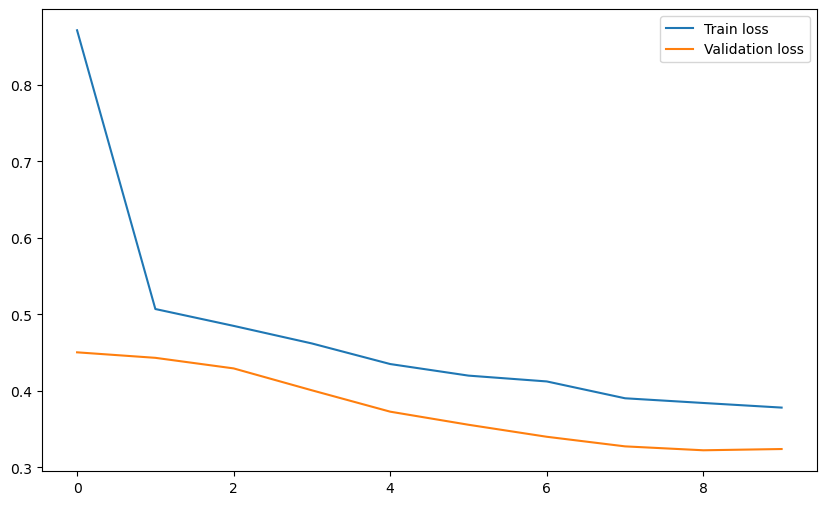

In [36]:
plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], label = "Train loss")
plt.plot(hist.history['val_loss'], label = "Validation loss")
plt.legend()
plt.show()

## Model Prediction

In [39]:
def predict_func(img): 
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    img = cv2.resize(img, (224, 224))
    img = np.reshape(img, [-1, 224, 224,3])
    result = np.argmax(model.predict(img))
    if result == 0: print("\033[94m"+"This image -> Recyclable"+"\033[0m")
    elif result ==1: print("\033[94m"+"This image -> Organic"+"\033[0m")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


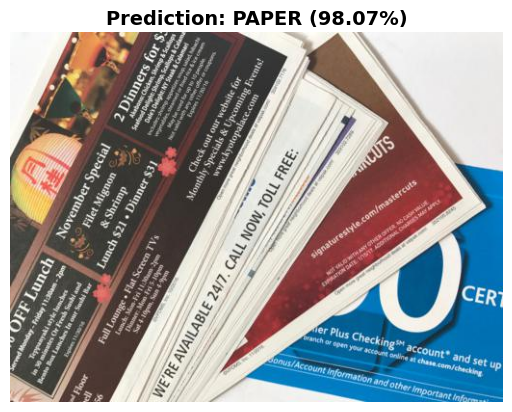

('paper', 0.98069364)

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_func(img):
    # Check if image loaded correctly
    if img is None:
        print("Error: Could not read the image. Check the file path.")
        return None, None

    # 1. Convert OpenCV BGR format to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Resize image to match model input shape (224x224)
    img_resized = cv2.resize(img_rgb, (224, 224))
    
    # 3. Rescale pixel values (matching ImageDataGenerator rescale=1./255)
    img_normalized = img_resized / 255.0
    
    # 4. Expand dimensions to create a batch size of 1 -> (1, 224, 224, 3)
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # 5. Run inference
    predictions = model.predict(img_batch)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx]
    
    # Extract class labels directly from train_generator mapping
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_idx]
    
    # 6. Display results and image
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_label.upper()} ({confidence*100:.2f}%)", 
              fontdict={'size': 14, 'weight': 'bold'})
    plt.axis('off')
    plt.show()
    
    return predicted_label, confidence

# Execute prediction on test image
test_img_path = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\paper\paper100.jpg"
test_img = cv2.imread(test_img_path)
predict_func(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


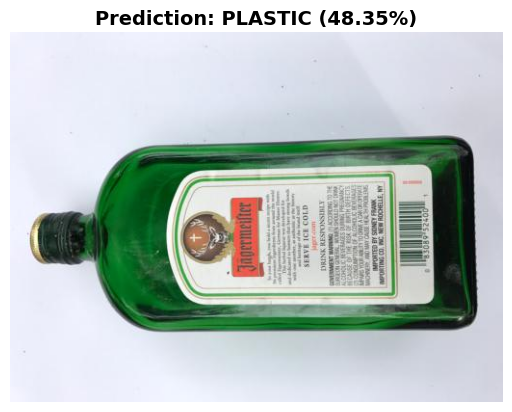

In [41]:
import cv2

# Local path to an image in your dataset (e.g., recyclable or organic/glass/paper item)
test_img_path = r"C:\Users\LENOVO\Downloads\archive (1)\dataset-resized\glass\glass100.jpg"

# Read image
test_img = cv2.imread(test_img_path)

# Run prediction
if test_img is not None:
    predict_func(test_img)
else:
    print(f"Failed to load image at: {test_img_path}")

In [42]:
import pickle

# Define file name
pkl_filename = "waste_classifier_model.pkl"

# Save the trained model to disk
with open(pkl_filename, "wb") as file:
    pickle.dump(model, file)

print(f"Model successfully saved as '{pkl_filename}' in your working directory.")

Model successfully saved as 'waste_classifier_model.pkl' in your working directory.


In [1]:
!pip install gradio

  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/31.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/31.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/31.3 MB ? eta -:--:--
    --------------------------------------- 0.5/31.3 MB 699.0 kB/s eta 0:00:45
    -------------------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.0 which is incompatible.
